# EDA (Day-1)

### Importing Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading final.csv dataset

In [3]:
df = pd.read_csv('/home/arpitsaxena/Desktop/TSE/Week-6/src/data/processed/final.csv')

In [24]:
print(df.shape)

(407161, 9)


### Converting each column to numeric, non-convertible become NaN

In [25]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipykernel_130685/2907331251.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


### Printing Categorical and Numerical features

In [26]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: Index(['Quantity', 'UnitPrice', 'CustomerID', 'TotalPrice'], dtype='object')
Categorical columns: Index(['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country'], dtype='object')


### Correlation Matrix

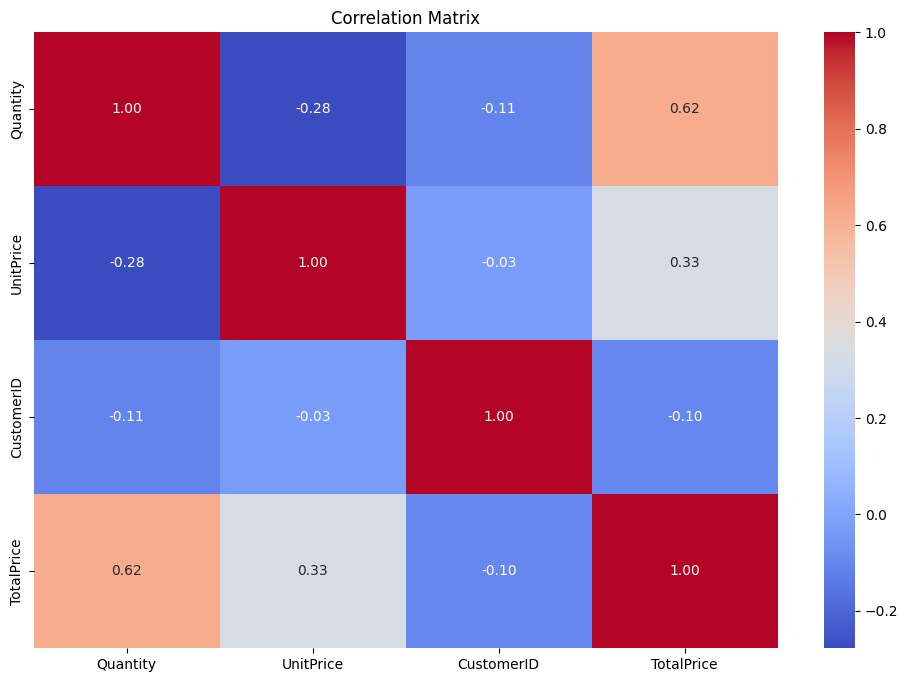

In [27]:
if len(numeric_features) > 1:
    plt.figure(figsize=(12, 8))
    corr_matrix = df[numeric_features].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")


### Distribution Graph for Numeric features

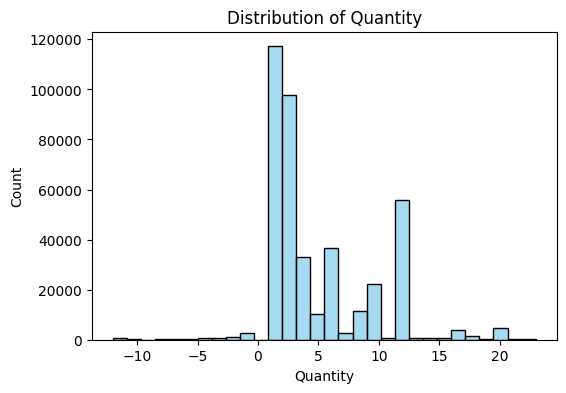

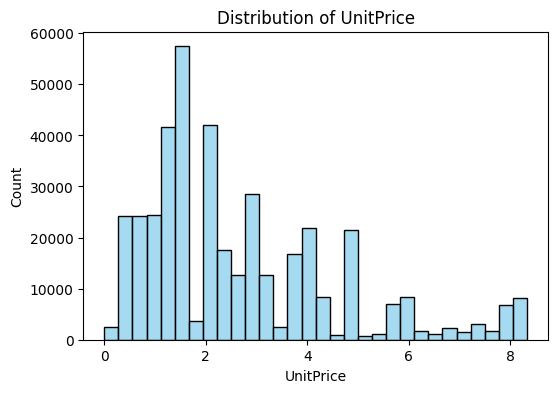

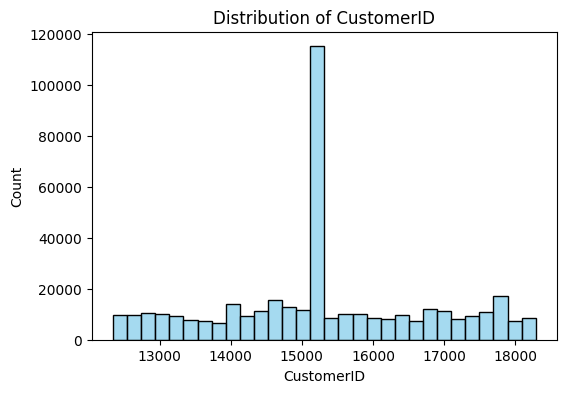

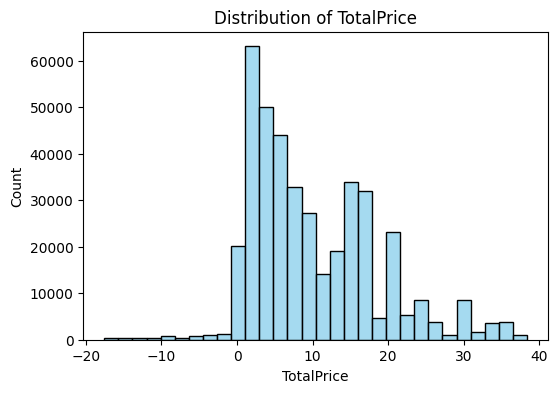

In [8]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=False, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

### Target Distribution Graph

### Missing values heatmap (along with missing summary)

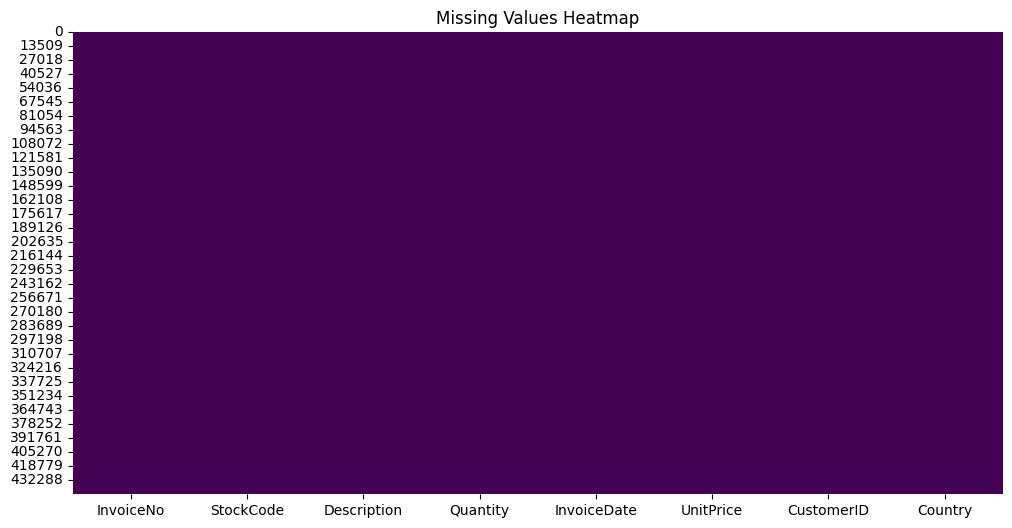

Missing Values per Column:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

missing_summary = df.isnull().sum()
print("Missing Values per Column:")
print(missing_summary)

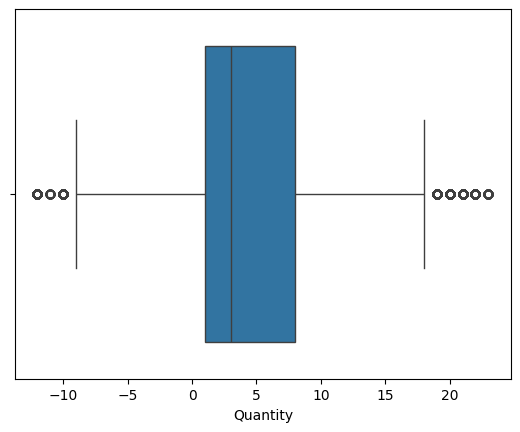

In [ ]:
sns.boxplot(x=df['Quantity'])
Q1, Q3 = df['Quantity'].quantile([0.25, 0.75])


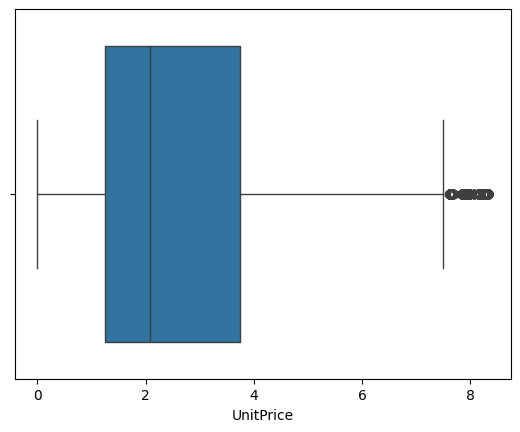

In [ ]:
sns.boxplot(x=df['UnitPrice'])
Q1, Q3 = df['UnitPrice'].quantile([0.25, 0.75])
